## Linear Regression Practical Implementation

In [1]:
import pandas as pd
from sklearn.datasets import load_boston

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = load_boston()

data_set = pd.DataFrame(df.data, columns=df.feature_names)
data_set.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


#### x and y seperation

In [11]:
x = data_set
y = df.target

In [12]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [14]:
# Split data into training and testing set

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30, random_state=45)

In [16]:
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)
print("----------------------------")
print("Shape of y_train: ",x_test.shape)
print("Shape of y_train: ",y_test.shape)

Shape of x_train:  (354, 13)
Shape of y_train:  (354,)
----------------------------
Shape of y_train:  (152, 13)
Shape of y_train:  (152,)


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import r2_score

The process of Cross Validation:
1. The data is divided into k equal-sized part (or "folds")
2. The model is trained on k-1 fold and test on the ramaining folds or chunks.
3. This process is repeated k times, with a different fold used as the test set each time.
4. The performance metrics (like accuracy, precious etc) are averaged over the k runs to give a more reliable estimate.


Ex:
1. split data into 5 chunks: ABCDE
2. Train on BCDE and test on A
3. Train on ACDE and test on B
4. Train on ABDE and test on C
5. Train on ABCE and test on D
6. Train on ABCD and test on E
7. Average the 5 performance scores.

In [24]:
# Standerdizing dataset
st = StandardScaler()
x_train = st.fit_transform(x_train)
x_test = st.transform(x_test)

In [25]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [26]:
scores = cross_val_score(lr, x_train, y_train, scoring='neg_mean_squared_error', cv=6)
scores

array([-13.88435895, -38.57571969, -25.81864782, -14.8008486 ,
       -21.9735737 , -28.07983764])

In [27]:
np.mean(scores)

-23.855497734567127

In [30]:
reg_pred = lr.predict(x_test) # prediction

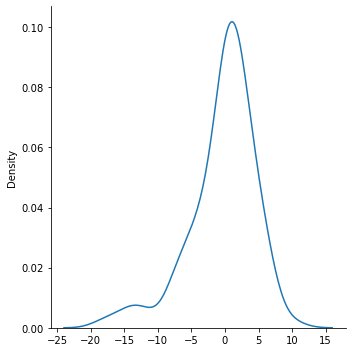

In [35]:
sns.displot(reg_pred-y_test, kind='kde')

In [37]:
r2_score(reg_pred, y_test)

0.624971333850757